# Exploratory Analysis of Daily Burned Area in Spain (1983–2022)
This notebook presents an exploratory analysis of a high-resolution spatiotemporal dataset on wildfires in Spain, covering the period from January 2, 1983 to January 1, 2022. The dataset contains daily estimates of burned area derived from satellite observations.

The analysis is carried out using standard Python tools for data science and geospatial analysis, including xarray for handling multidimensional arrays, pandas for data manipulation, and matplotlib for visualization. The notebook performs basic yet informative calculations to illustrate the structure and potential of the dataset, including spatial statistics, temporal patterns, and data aggregation.

The aim is to provide a clear and reproducible workflow that can serve as a starting point for fire-related research and spatial analysis using open-source Python tools.

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

## Data Extraction

In [61]:
ds = xr.open_dataset('../raster_outputs/r025/firespain_025_WGS84_v0.3.nc')
data_burned = ds['ba']

## Spatial Statistics Computation

### Mean Burned Area

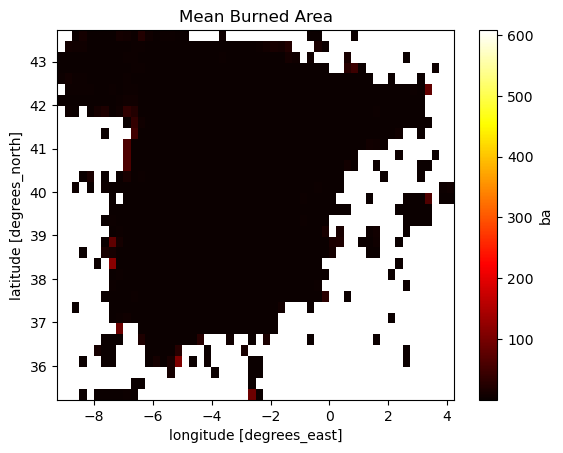

In [73]:
#Average over time
mean_burned = data_burned.mean(dim='time')
mean_burned.plot(cmap='hot')
plt.title(f"Mean Burned Area")
plt.show()

### Total Wildfire Counts

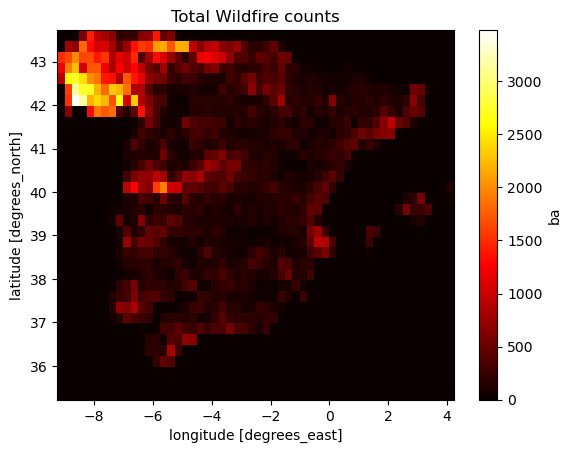

In [70]:
#Count how many times the value > 0
count_gt_zero = (data_burned > 0).sum(dim='time')
count_gt_zero.plot(cmap='hot')
plt.title(f"Total Wildfire counts")
plt.show()

### Wildfire Relative Frequency

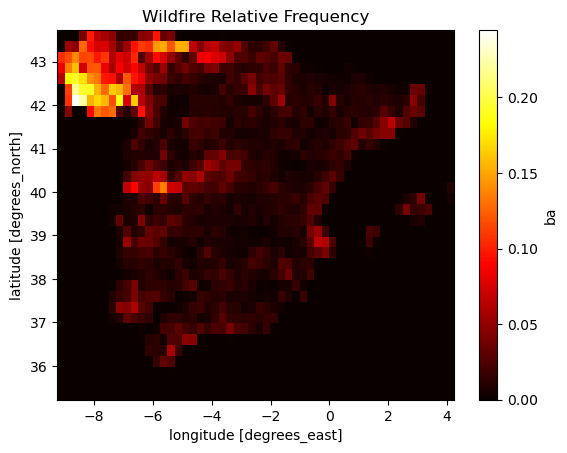

In [71]:
mean_pos = (data_burned > 0).mean(dim='time')
mean_pos.plot(cmap='hot')
plt.title(f"Wildfire Relative Frequency")
plt.show()

## Convert the grid into a DataFrame

In [74]:
df = ds.to_dataframe().reset_index()
df.head()

,longitude,latitude,time,ba
0,-9.135475,43.601416,1983-01-02 12:00:00,NaN
1,-9.135475,43.601416,1983-01-03 12:00:00,NaN
2,-9.135475,43.601416,1983-01-04 12:00:00,NaN
3,-9.135475,43.601416,1983-01-05 12:00:00,NaN
4,-9.135475,43.601416,1983-01-06 12:00:00,NaN


## Temporal Evolution of Burned Area

### Pixel-Level Time Series

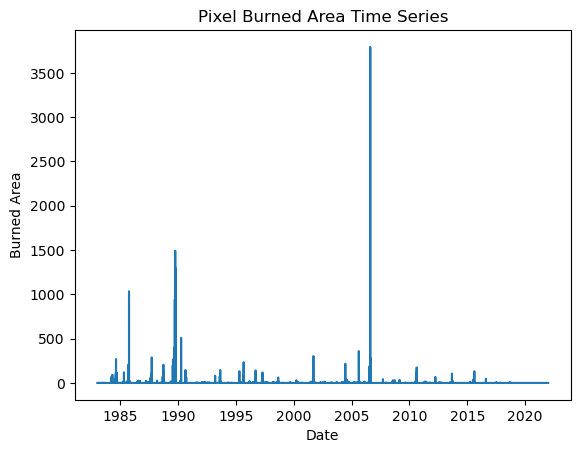

In [147]:
df_pixel = df[(round(df['latitude'], 6) == 43.101416) & (round(df['longitude'],6) == -9.135475)].dropna()
plt.plot(df_pixel['time'], df_pixel['ba'])
plt.title('Pixel Burned Area Time Series')
plt.ylabel('Burned Area')
plt.xlabel('Date')
plt.show()

### National Time Series

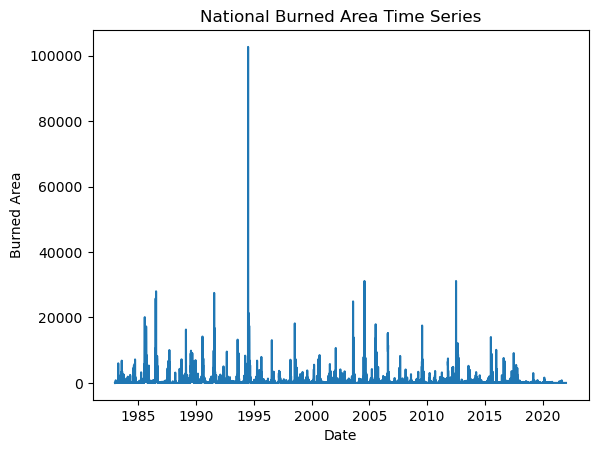

In [148]:
df_total = df.groupby(['time']).sum()['ba'].reset_index()
plt.plot(df_total['time'], df_total['ba'])
plt.title('National Burned Area Time Series')
plt.ylabel('Burned Area')
plt.xlabel('Date')
plt.show()

### Spatial Upscaling

In [153]:
resolutions = {
    '0.5': 2,
    '1.0': 4,
    '1.5': 6
}

upscaled_versions = {}
upscaled_versions['0.25'] = burned
for res, factor in resolutions.items():
    upscaled = burned.coarsen(latitude=factor, longitude=factor, boundary='trim').sum()
    upscaled_versions[res] = upscaled
    #upscaled.to_netcdf(f"burned_area_upscaled_{res}deg.nc")


We have our data upscaled into different grid resolutions we can now calculate some statistics per pixel in each grid:

In [154]:
grid_statistics = {}
for res, factor in upscaled_versions.items():
    data_burned = upscaled_versions[res]
    #Mean Burned Area
    mean_burned = data_burned.mean(dim='time')
    #Total Wildfire Counts
    count_gt_zero = (data_burned > 0).sum(dim='time')
    #Wildfire Relative Frequency
    mean_pos =(data_burned > 0).mean(dim='time')
    grid_statistics.update({res : {'mean':mean_burned,'count' : count_gt_zero, 'meanDiffZero' : mean_pos}})

Once we upscaled the grids into different resolutions, we can represent it in different maps

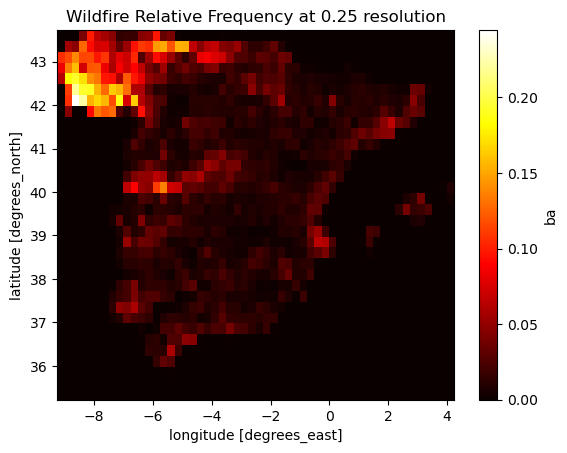

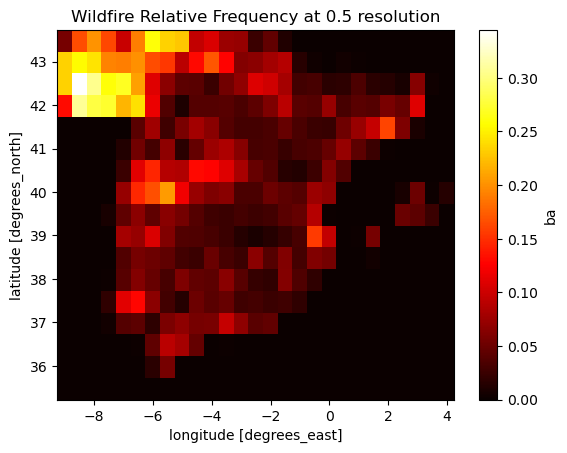

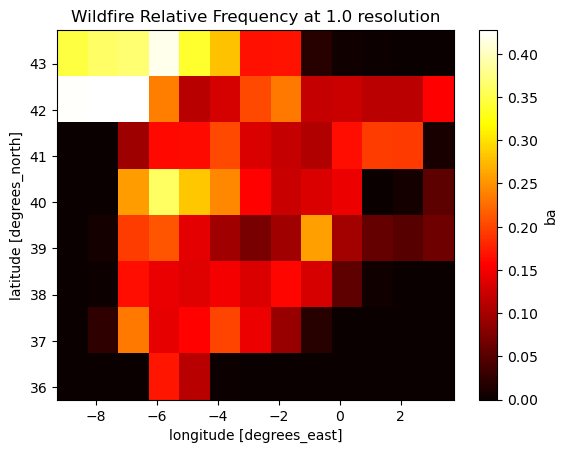

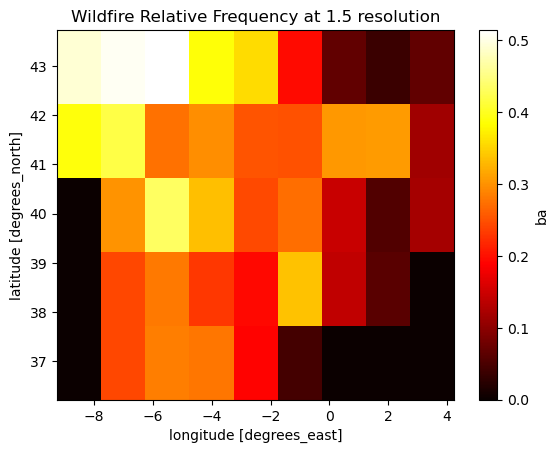

In [155]:
for res,grid in grid_statistics.items():
        burned_2d = grid_statistics[res]['meanDiffZero']

        # Gráfico simple
        burned_2d.plot(cmap='hot')
        plt.title(f"Wildfire Relative Frequency at {res} resolution")
        plt.show()